In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

import pymc as pm
import pytensor.tensor as pt
import pytensor
pytensor.config.cxx = '/usr/bin/clang++'

In [2]:
# helpers
def binomial(n_samples, theta_like=0.7, seed=20):
    np.random.seed(seed)
    data = np.random.binomial(n_samples, theta_like)
    return data

def load_config(config_file="config.json"):

    with open(config_file, 'r') as f:
        config = json.load(f)
    return config

def beta_posterior(successes, trials, alpha_0, beta_0):
    alpha_post = alpha_0 + successes
    beta_post = beta_0 + trials - successes
    mean_post = alpha_post / (alpha_post + beta_post)
    var_post = (alpha_post * beta_post) / ((alpha_post + beta_post) ** 2 * (alpha_post + beta_post + 1))
    return {
        'alpha_post': alpha_post,
        'beta_post': beta_post,
        'mean_post': mean_post,
        'std_post': np.sqrt(var_post)
    }

from scipy.special import expit  # sigmoid

def _logistic_normal_mean_std_mc(mu, sigma, n_samples=10_000, seed=0):
    mu = float(np.squeeze(mu))
    sigma = float(np.squeeze(sigma))
    rng = np.random.default_rng(seed)
    z = rng.normal(loc=mu, scale=sigma, size=n_samples)
    theta = expit(z)
    return float(theta.mean()), float(theta.std(ddof=1))

def _trace_locscale_to_theta_moments(loc_trace, scale_trace, n_samples=10_000, seed=0):
    loc_trace = np.asarray(loc_trace, dtype=float)
    scale_trace = np.asarray(scale_trace, dtype=float)
    out_mean = np.empty(loc_trace.shape[0], dtype=float)
    out_std  = np.empty(loc_trace.shape[0], dtype=float)
    for i in range(loc_trace.shape[0]):
        out_mean[i], out_std[i] = _logistic_normal_mean_std_mc(
            loc_trace[i], scale_trace[i], n_samples=n_samples, seed=seed
        )
    return out_mean, out_std

data_gen = binomial

In [3]:
config_file = "../beta_config.json"
config = load_config(config_file)

theta_like = config['theta_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']
grad_samps = config['grad_samps']
max_iters = 100_000
adam_step = config['adam_step']

data = data_gen(n_samples) if n_samples > 0 else 0
# print parameters
print("prior: Beta({}, {})".format(alpha_prior, beta_prior))
print("Likelihood: Binomial({})".format(theta_like))
print(data)
true_post = beta_posterior(data, n_samples, alpha_prior, beta_prior)
print("True posterior: Beta({}, {:.2f})".format(true_post['alpha_post'], true_post['beta_post']) + " with mean {:.2f} and std {:.2f}".format(true_post['mean_post'], true_post['std_post']))
# Note that our plots do compare to the "best variational approximation"

prior: Beta(0.5, 0.6)
Likelihood: Binomial(0.7)
7
True posterior: Beta(7.5, 3.60) with mean 0.68 and std 0.13


In [4]:
# copy-pasted from beta_pymc.ipynb

def run_model(n_mc_samples = 1, optimizer = 'default', seed = 1):
        
    with pm.Model() as single_model:
        # Define the prior
        theta = pm.Beta('theta', alpha=alpha_prior, beta=beta_prior)

        # Define the likelihood
        y = pm.Binomial('y', n=n_samples, p=theta, observed=data)

        advi = pm.ADVI(random_seed=seed)

        tracker = pm.callbacks.Tracker(
            mean=advi.approx.mean.eval,
            std=advi.approx.std.eval,
        )

        if optimizer == 'default':
            approx = advi.fit(
                max_iters, callbacks=[tracker],
                progressbar=False,
                obj_n_mc=n_mc_samples
            )
        else:
            approx = advi.fit(
                max_iters, callbacks=[tracker],
                progressbar=False,
                obj_n_mc=n_mc_samples,
                obj_optimizer=pm.adam()
            )
    return tracker['mean'], tracker['std']

def run_restart(seed, optimizer='default'):
    single_means, single_stds = run_model(seed=seed, optimizer=optimizer)
    single_mus, single_sigmas = _trace_locscale_to_theta_moments(
        single_means, single_stds, n_samples=50_000, seed=seed)
    multi_means, multi_stds = run_model(100, optimizer=optimizer, seed=seed+1000)
    multi_mus, multi_sigmas = _trace_locscale_to_theta_moments(
        multi_means, multi_stds, n_samples=50_000, seed=seed+1000)
    return [single_mus, single_sigmas], [multi_mus, multi_sigmas]


In [ ]:
seeds = np.arange(100)
results = [run_restart(seed) for seed in tqdm(seeds, position=0)]
results_adam = [run_restart(seed, 'adam') for seed in tqdm(seeds, position=0)]

  0%|          | 0/100 [00:00<?, ?it/s]

Finished [100%]: Average Loss = 2.731
Finished [100%]: Average Loss = 2.7305
Finished [100%]: Average Loss = 2.7423
Finished [100%]: Average Loss = 2.7304
Finished [100%]: Average Loss = 2.7373
Finished [100%]: Average Loss = 2.7303
Finished [100%]: Average Loss = 2.7457
Finished [100%]: Average Loss = 2.7304
Finished [100%]: Average Loss = 2.7294
Finished [100%]: Average Loss = 2.7302
Finished [100%]: Average Loss = 2.735
Finished [100%]: Average Loss = 2.7297
Finished [100%]: Average Loss = 2.7381
Finished [100%]: Average Loss = 2.7305
Finished [100%]: Average Loss = 2.7347
Finished [100%]: Average Loss = 2.7306
Finished [100%]: Average Loss = 2.7274
Finished [100%]: Average Loss = 2.7303
Finished [100%]: Average Loss = 2.7421
Finished [100%]: Average Loss = 2.7299
Finished [100%]: Average Loss = 2.7381
Finished [100%]: Average Loss = 2.7302
Finished [100%]: Average Loss = 2.7409
Finished [100%]: Average Loss = 2.7302
Finished [100%]: Average Loss = 2.7431
Finished [100%]: Average Lo

In [ ]:
plt.rcParams.update({'font.size': 20})
# ----------------------------
# unpack results -> stacks
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []
for single_tracker, multi_tracker in results:
    single_means.append(single_tracker[0])
    single_stds.append(single_tracker[1])
    multi_means.append(multi_tracker[0])
    multi_stds.append(multi_tracker[1])

single_means = np.stack(single_means, axis=0)  # (N, T)
single_stds  = np.stack(single_stds,  axis=0)  # (N, T)
multi_means  = np.stack(multi_means,  axis=0)  # (N, T)
multi_stds   = np.stack(multi_stds,   axis=0)  # (N, T)

N, T = single_means.shape
single_means = single_means.reshape(N, T)
single_stds  = single_stds.reshape(N, T)
multi_means  = multi_means.reshape(N, T)
multi_stds   = multi_stds.reshape(N, T)
x = np.arange(T)

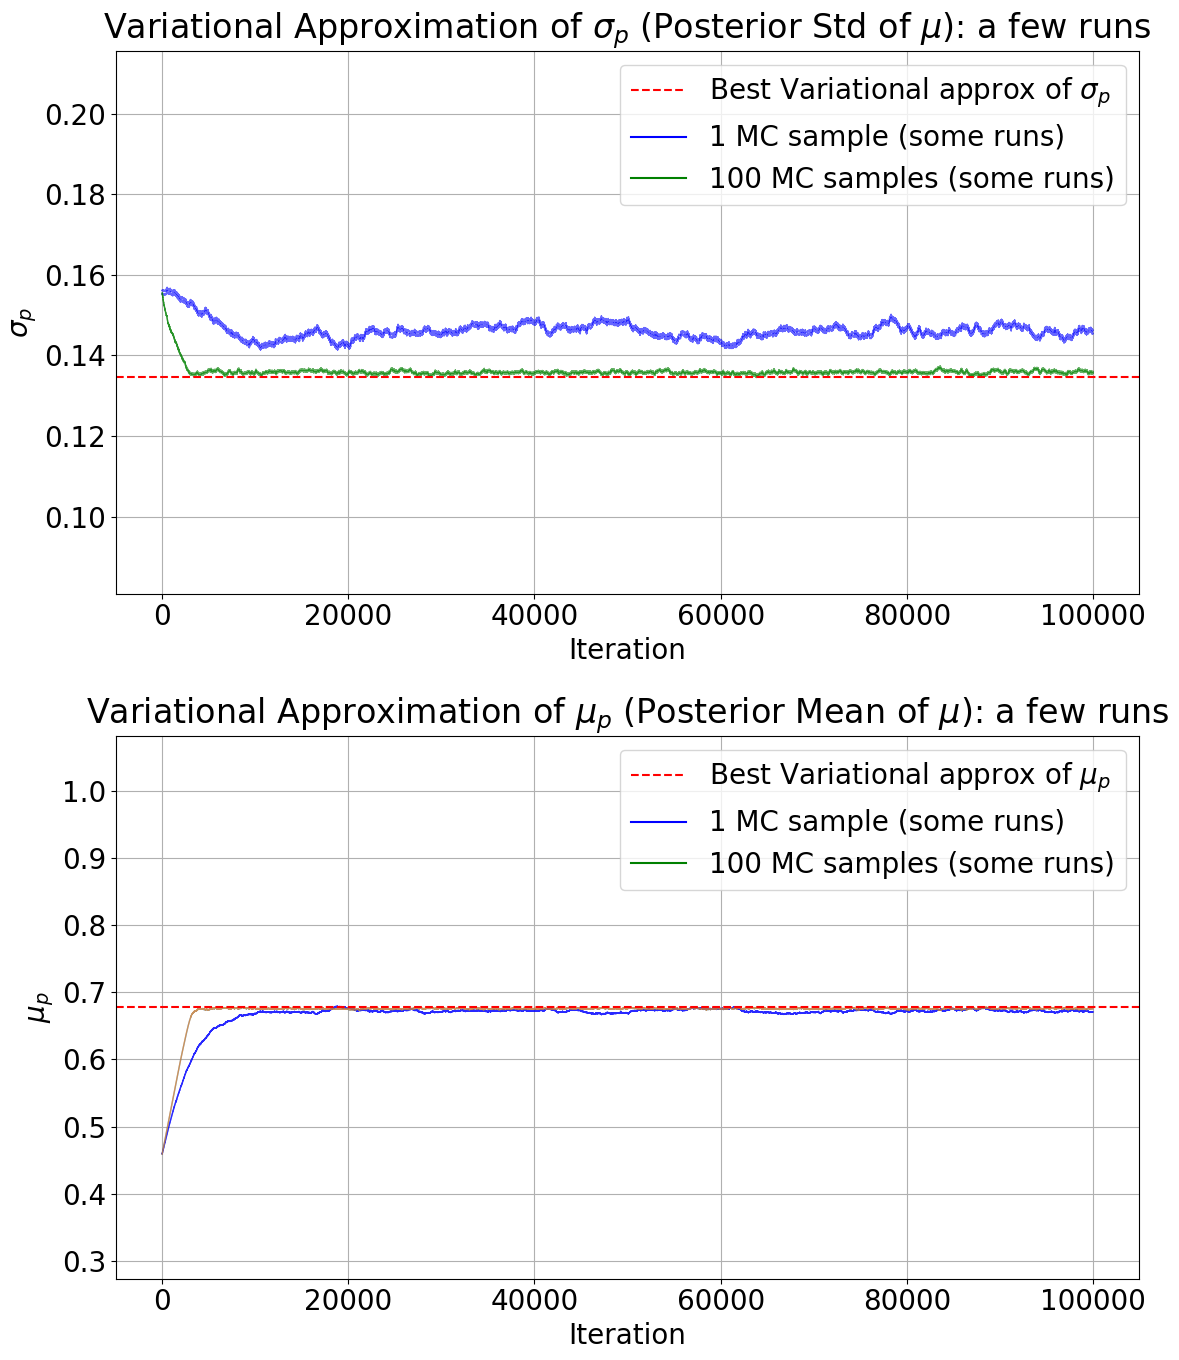

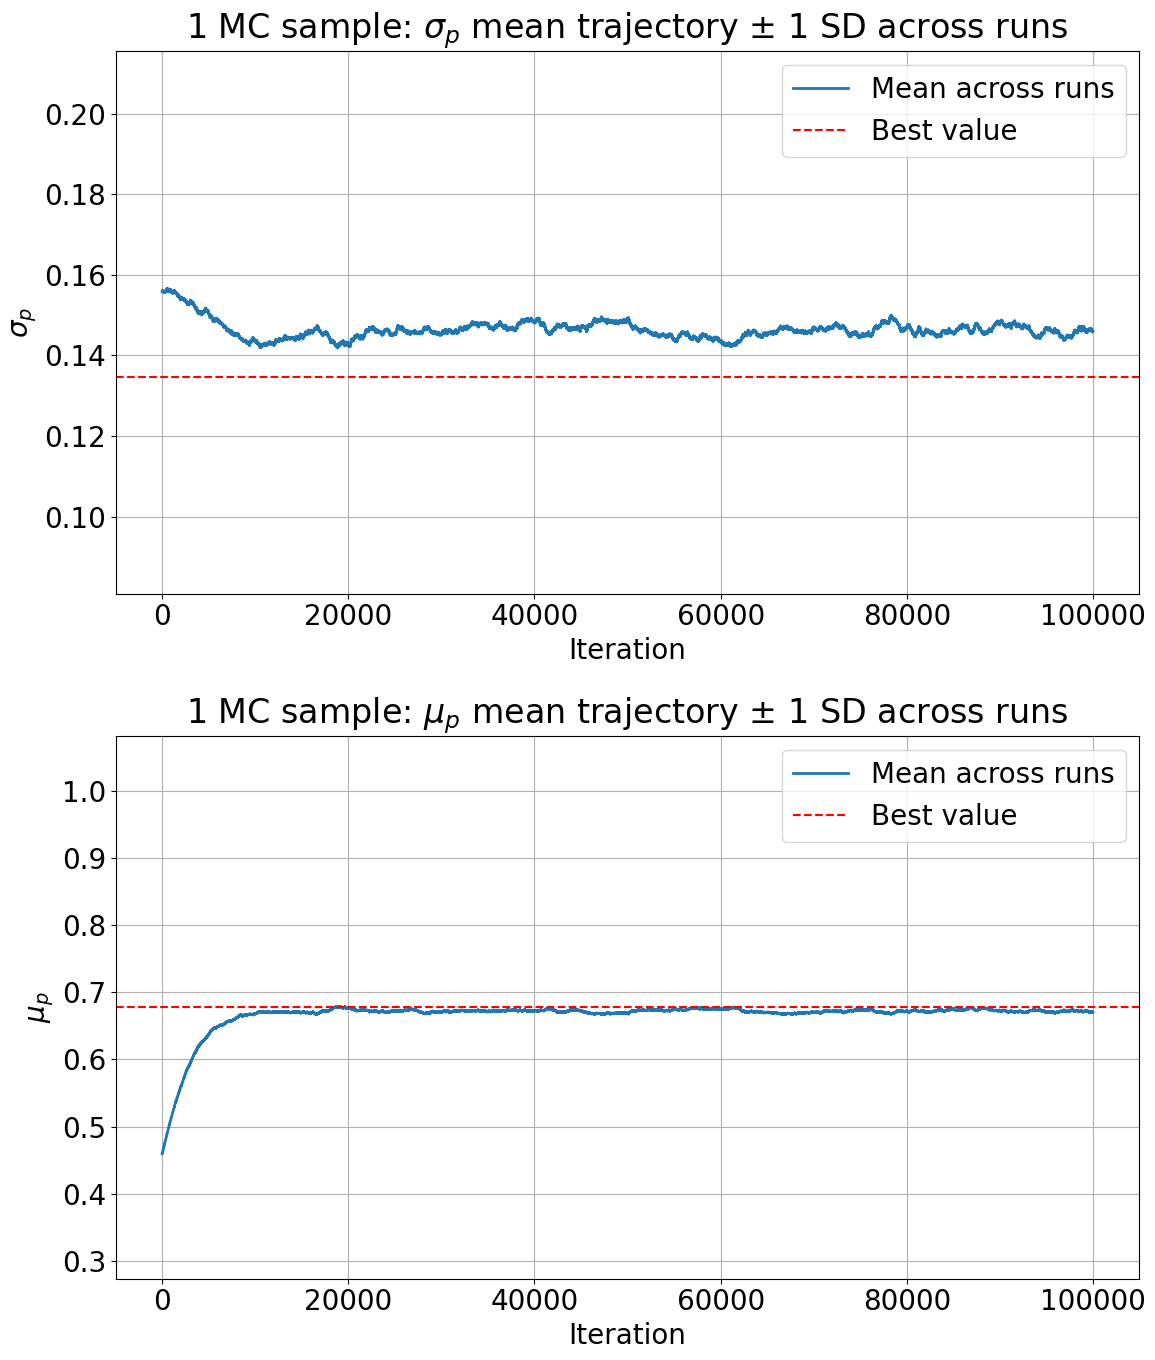

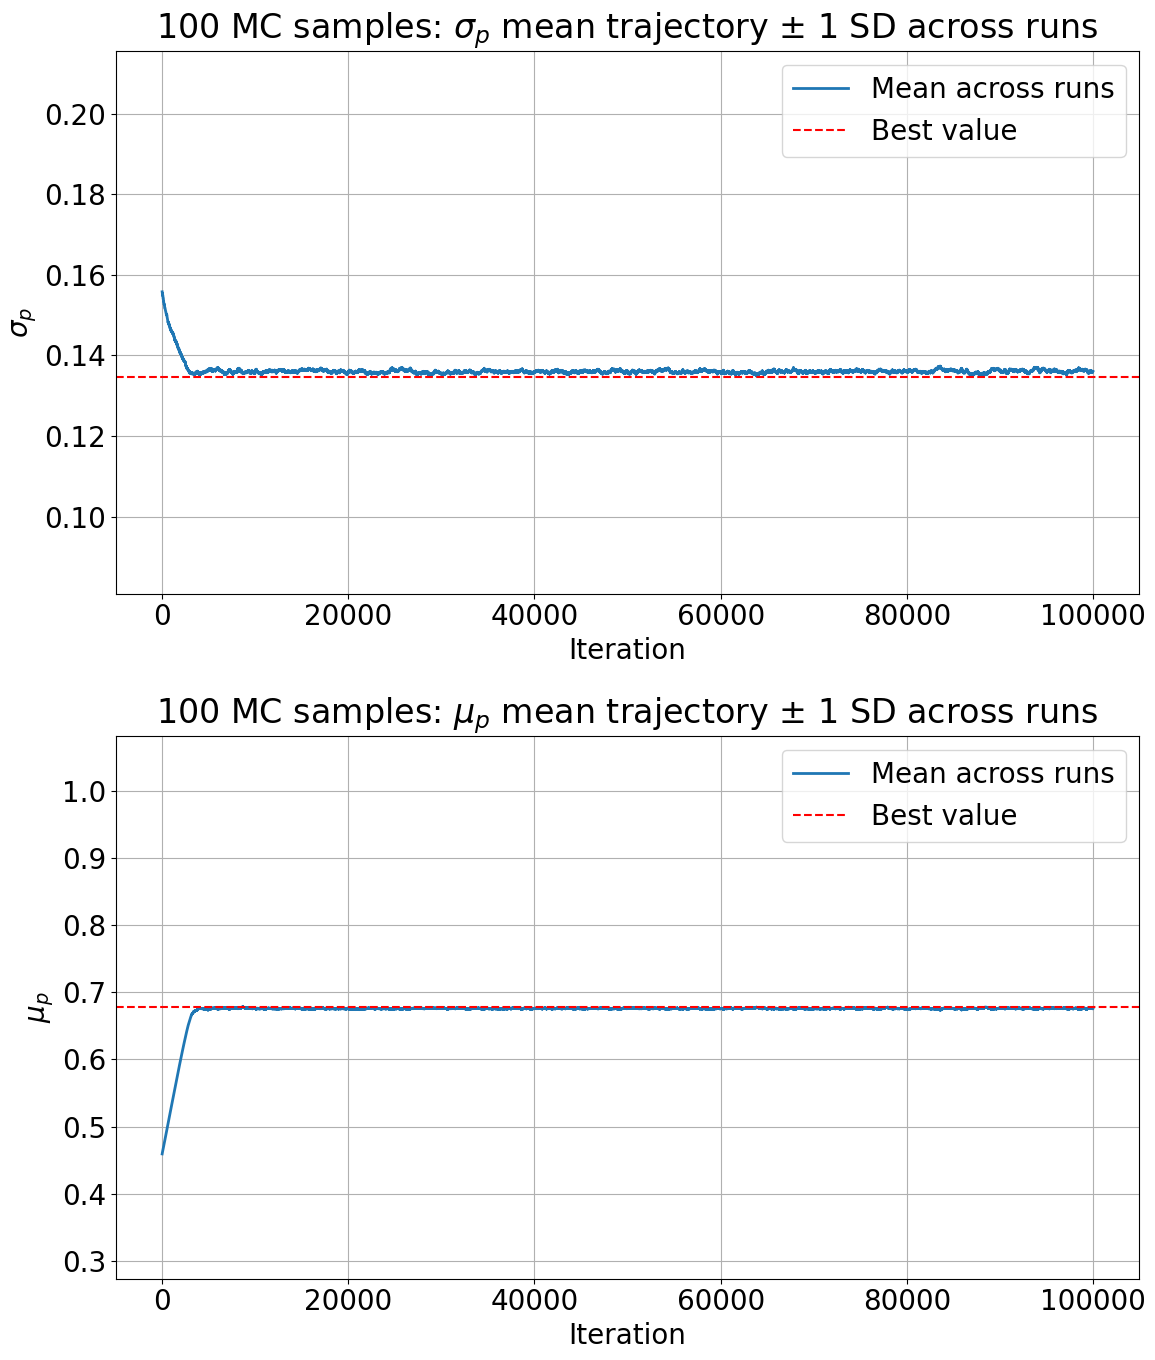

In [ ]:
# If we have "best" from config, these should be on theta-scale (0,1)
best_mu = float(config["best_mean"]) if "config" in globals() and "best_mean" in config else None
best_std = float(config["best_std"]) if "config" in globals() and "best_std" in config else None
best_mu, best_std = _logistic_normal_mean_std_mc(best_mu, best_std, n_samples=50_000, seed=1)

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(best_std, color='red', linestyle='--', label=r'Best Variational approx of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(best_mu, color='red', linestyle='--', label=r'Best Variational approx of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='Best value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()

# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds, best_std,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

plot_mean_band(
    axs[1], x, single_means, best_mu,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds, best_std,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

plot_mean_band(
    axs[1], x, multi_means, best_mu,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()

In [ ]:
# now let's look at the adam results

# Adam results

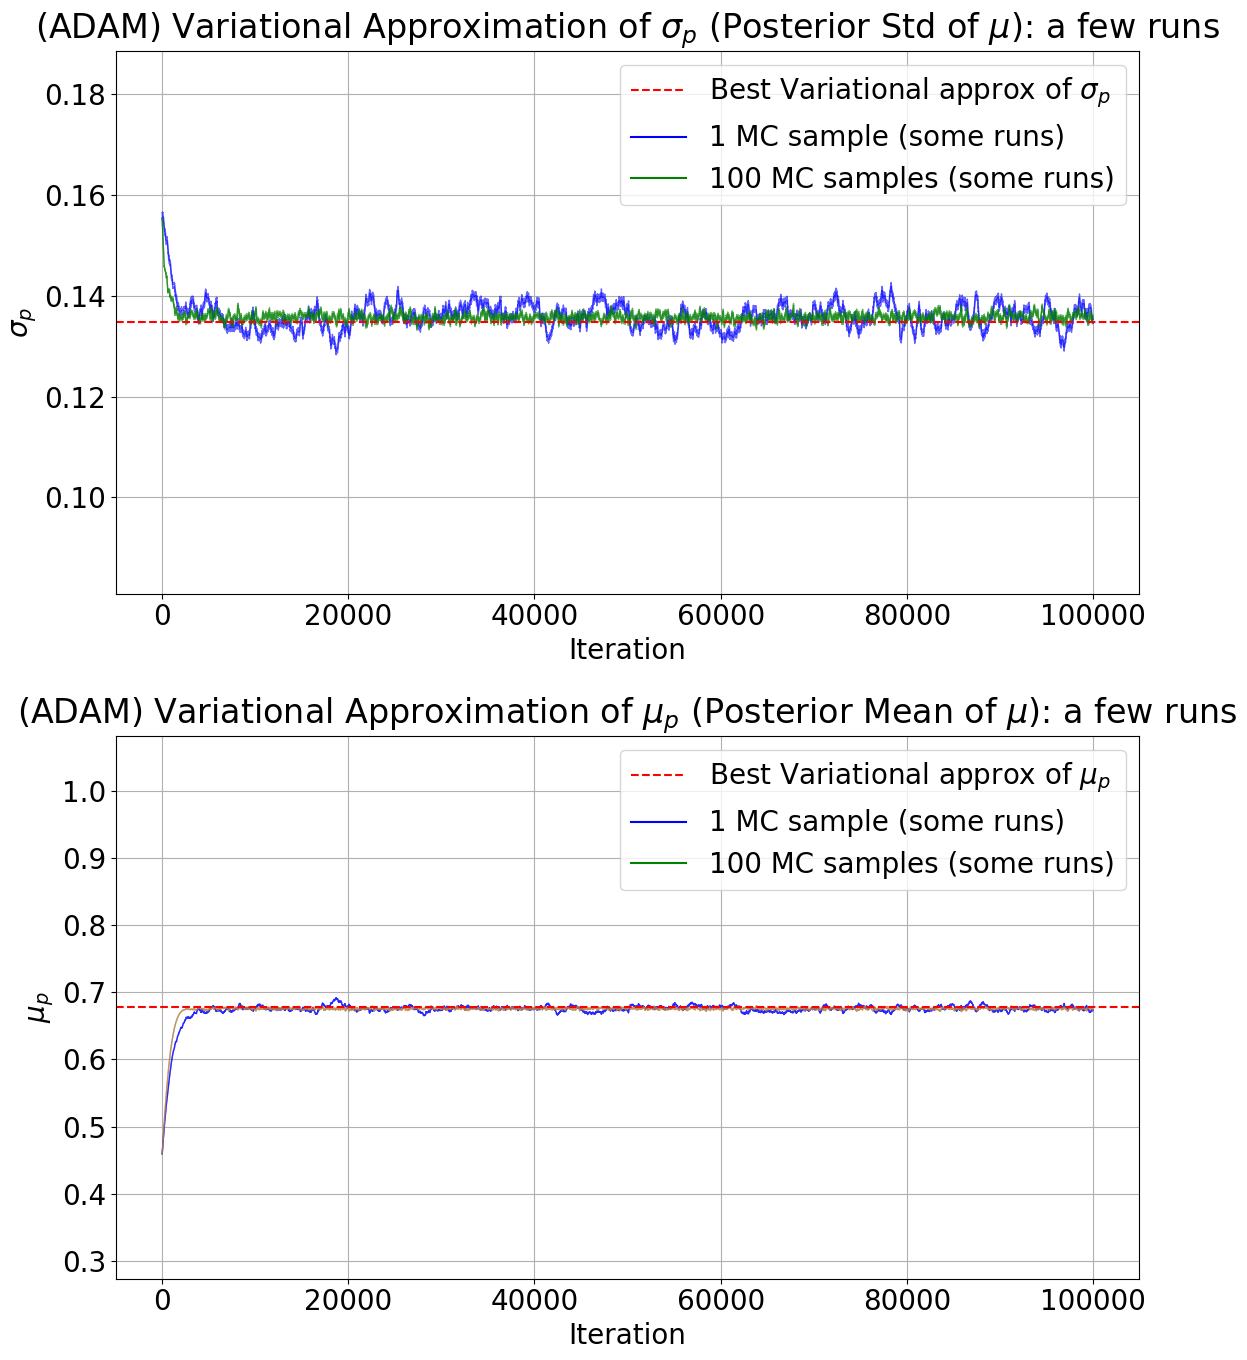

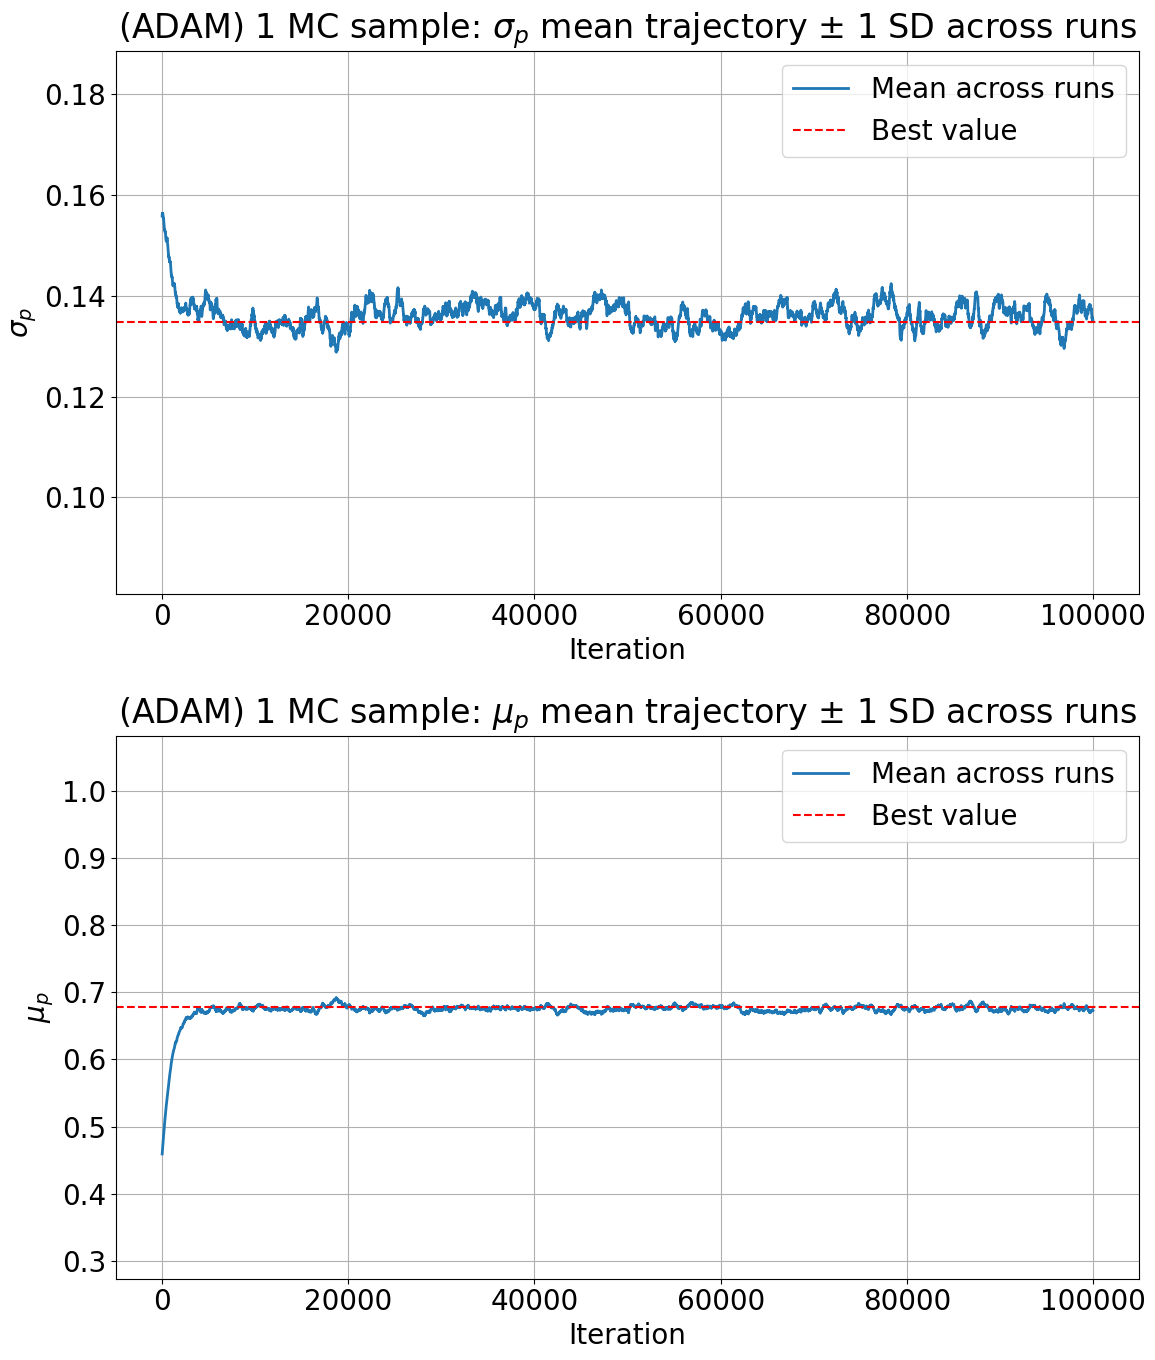

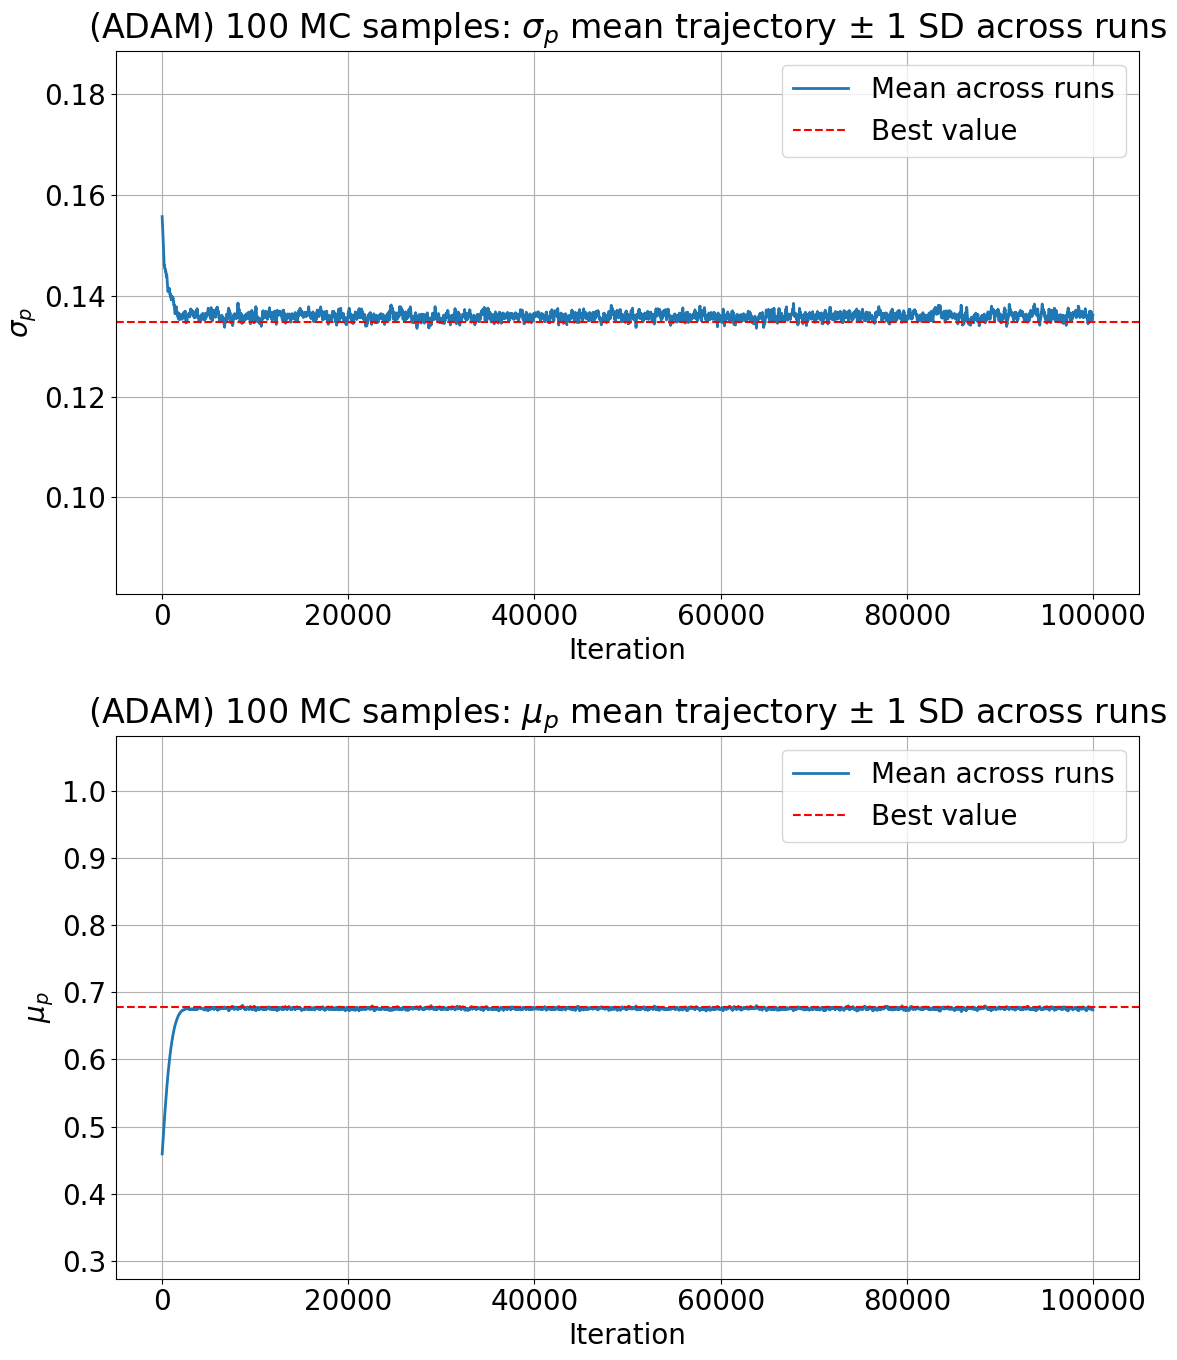

In [ ]:
# ----------------------------
# unpack results -> stacks
# ----------------------------
single_means_adam, single_stds_adam = [], []
multi_means_adam,  multi_stds_adam  = [], []
for single_tracker_adam, multi_tracker_adam in results_adam:
    single_means_adam.append(single_tracker_adam[0])
    single_stds_adam.append(single_tracker_adam[1])
    multi_means_adam.append(multi_tracker_adam[0])
    multi_stds_adam.append(multi_tracker_adam[1])

single_means_adam = np.stack(single_means_adam, axis=0)  # (N, T)
single_stds_adam  = np.stack(single_stds_adam,  axis=0)  # (N, T)
multi_means_adam  = np.stack(multi_means_adam,  axis=0)  # (N, T)
multi_stds_adam   = np.stack(multi_stds_adam,   axis=0)  # (N, T)

N, T = single_means_adam.shape
single_means_adam = single_means_adam.reshape(N, T)
single_stds_adam  = single_stds_adam.reshape(N, T)
multi_means_adam  = multi_means_adam.reshape(N, T)
multi_stds_adam   = multi_stds_adam.reshape(N, T)
x = np.arange(T)

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds_adam[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds_adam[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(best_std, color='red', linestyle='--', label=r'Best Variational approx of $\sigma_p$')
axs[0].set_title(r'(ADAM) Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(best_std * 0.6, best_std * 1.4)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means_adam[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means_adam[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(best_mu, color='red', linestyle='--', label=r'Best Variational approx of $\mu_p$')
axs[1].set_title(r'(ADAM) Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------


# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds_adam, best_std,
    r'(ADAM) 1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.4)

plot_mean_band(
    axs[1], x, single_means_adam, best_mu,
    r'(ADAM) 1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds_adam, best_std,
    r'(ADAM) 100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.4)

plot_mean_band(
    axs[1], x, multi_means_adam, best_mu,
    r'(ADAM) 100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()